# Performance Analytics — Day 4
**Daily Returns | CAGR | Sharpe | Sortino | Alpha/Beta | Max Drawdown | Fund Scorecard | Benchmark Comparison**

In [2]:
import os
from pathlib import Path

def find_project_root(start=Path.cwd()):
    current = start
    for _ in range(5):
        if (current / "data").exists() and (current / "scripts").exists():
            return current
        current = current.parent
    raise FileNotFoundError("Could not locate project root (folder with data/ and scripts/)")

os.chdir(find_project_root())
print("Working directory set to:", os.getcwd())

import pandas as pd, numpy as np, matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings; warnings.filterwarnings('ignore')
fm   = pd.read_csv('data/raw/01_fund_master.csv')
nav  = pd.read_csv('data/raw/02_nav_history.csv', parse_dates=['date'])
bm   = pd.read_csv('data/raw/10_benchmark_indices.csv', parse_dates=['date'])
nav  = nav.sort_values(['amfi_code','date'])
RF   = 0.065 / 252  # RBI repo rate proxy daily
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()
n100 = bm[bm['index_name']=='NIFTY100'].set_index('date')['close_value'].pct_change().dropna()
n50  = bm[bm['index_name']=='NIFTY50'].set_index('date')['close_value'].pct_change().dropna()
print("All data loaded ✓")
print("Daily return distribution:")
print(nav['daily_return'].describe().round(6))

Working directory set to: C:\Projects\cp_project
All data loaded ✓
Daily return distribution:
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


## Task 1 — Daily Returns Validation

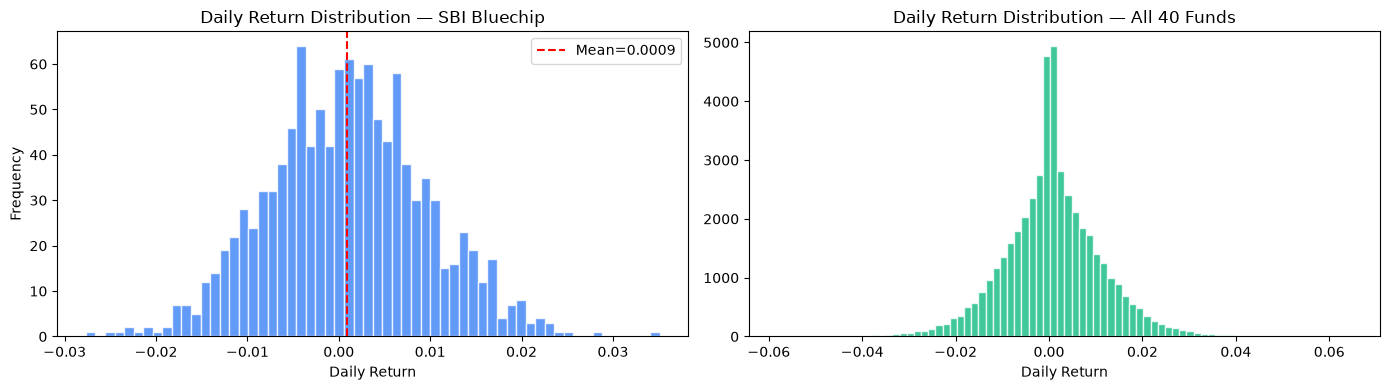

Max single-day gain : 6.47%
Max single-day loss : -5.81%
% positive days     : 54.5%


In [3]:

fig, axes = plt.subplots(1,2,figsize=(14,4))
sample = nav[nav['amfi_code']==119551]['daily_return'].dropna()
axes[0].hist(sample, bins=60, color='#3B82F6', edgecolor='white', alpha=0.8)
axes[0].set_title("Daily Return Distribution — SBI Bluechip"); axes[0].set_xlabel("Daily Return"); axes[0].set_ylabel("Frequency")
axes[0].axvline(sample.mean(), color='red', linestyle='--', label=f'Mean={sample.mean():.4f}')
axes[0].legend()
all_rets = nav['daily_return'].dropna()
axes[1].hist(all_rets, bins=80, color='#10B981', edgecolor='white', alpha=0.8)
axes[1].set_title("Daily Return Distribution — All 40 Funds"); axes[1].set_xlabel("Daily Return")
plt.tight_layout(); plt.savefig('reports/chart_daily_returns.png', dpi=150); plt.show()
print(f"Max single-day gain : {all_rets.max():.2%}")
print(f"Max single-day loss : {all_rets.min():.2%}")
print(f"% positive days     : {(all_rets>0).mean():.1%}")


## Task 2 — CAGR Comparison Table

In [4]:

def cagr(nav_series, years):
    end_date = nav_series.index.max()
    s = nav_series[nav_series.index >= end_date - pd.DateOffset(years=years)].dropna()
    if len(s)<10: return np.nan
    return ((s.iloc[-1]/s.iloc[0])**(1/years)-1)*100

cagr_rows = []
for code, grp in nav.groupby('amfi_code'):
    ns   = grp.sort_values('date').set_index('date')['nav']
    name = fm.loc[fm['amfi_code']==code,'scheme_name'].values[0]
    cat  = fm.loc[fm['amfi_code']==code,'category'].values[0]
    cagr_rows.append({'scheme_name':name,'category':cat,
                      'CAGR_1yr':round(cagr(ns,1),2),
                      'CAGR_3yr':round(cagr(ns,3),2),
                      'CAGR_5yr':round(cagr(ns,5),2)})

cagr_df = pd.DataFrame(cagr_rows).sort_values('CAGR_3yr', ascending=False)
print(cagr_df.to_string(index=False))


                                          scheme_name category  CAGR_1yr  CAGR_3yr  CAGR_5yr
                  Axis Midcap Fund - Regular - Growth   Equity     22.26     35.11     24.45
        Mirae Asset Large Cap Fund - Regular - Growth   Equity     20.36     34.00     26.80
            ICICI Pru Bluechip Fund - Direct - Growth   Equity     13.06     32.49     20.23
   HDFC Mid-Cap Opportunities Fund - Regular - Growth   Equity     53.23     32.44     26.07
             ICICI Pru Midcap Fund - Regular - Growth   Equity     29.60     31.78     28.38
            SBI Bluechip Fund - Regular Plan - Growth   Equity     60.44     30.46     22.38
               Kotak Flexicap Fund - Regular - Growth   Equity     26.66     29.58     26.74
        Mirae Asset Tax Saver Fund - Regular - Growth   Equity     39.75     29.18     27.63
        ABSL Frontline Equity Fund - Regular - Growth   Equity     47.92     28.97     20.44
                DSP Small Cap Fund - Regular - Growth   Equity     65.

## Task 3 — Sharpe Ratio Ranking

In [5]:
import pandas as pd
import numpy as np
from scipy import stats
from pathlib import Path

RAW = Path("data/raw")
PROC = Path("data/processed")
PROC.mkdir(parents=True, exist_ok=True)

fm = pd.read_csv(RAW / "01_fund_master.csv")
nav = pd.read_csv(RAW / "02_nav_history.csv", parse_dates=["date"])
bm = pd.read_csv(RAW / "10_benchmark_indices.csv", parse_dates=["date"])

nav = nav.sort_values(["amfi_code", "date"])
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

RF = 0.065 / 252  # RBI repo rate proxy, daily

n100 = bm[bm["index_name"] == "NIFTY100"].set_index("date")["close_value"].pct_change().dropna()

rows = []
for code, grp in nav.groupby("amfi_code"):
    grp = grp.sort_values("date").set_index("date")
    returns = grp["daily_return"].dropna()
    if len(returns) < 30:
        continue

    name = fm.loc[fm["amfi_code"] == code, "scheme_name"].values[0]
    category = fm.loc[fm["amfi_code"] == code, "category"].values[0]
    risk_category = fm.loc[fm["amfi_code"] == code, "risk_category"].values[0]
    expense_ratio = fm.loc[fm["amfi_code"] == code, "expense_ratio_pct"].values[0]

    # --- Sharpe Ratio: (Rp - Rf) / Std(Rp) * sqrt(252) ---
    sharpe = (returns.mean() - RF) / returns.std() * np.sqrt(252)

    # --- Sortino Ratio: same but denominator = downside deviation only ---
    downside = returns[returns < 0]
    downside_std = downside.std() if len(downside) > 1 else np.nan
    sortino = (returns.mean() - RF) / downside_std * np.sqrt(252) if downside_std and downside_std > 0 else np.nan

    # --- Alpha / Beta via OLS regression vs Nifty 100 ---
    common = returns.index.intersection(n100.index)
    if len(common) > 30:
        slope, intercept, r_value, p_value, std_err = stats.linregress(
            n100.loc[common].values, returns.loc[common].values
        )
        beta = slope
        alpha = intercept * 252  # annualized
    else:
        beta, alpha = np.nan, np.nan

    # --- Max Drawdown: min(NAV / running_max - 1) ---
    nav_series = grp["nav"]
    running_max = nav_series.cummax()
    drawdown = nav_series / running_max - 1
    max_dd = drawdown.min() * 100
    worst_dd_date = drawdown.idxmin()

    # --- 3yr return, for scorecard ranking ---
    end_date = nav_series.index.max()
    s3 = nav_series[nav_series.index >= end_date - pd.DateOffset(years=3)].dropna()
    cagr_3yr = ((s3.iloc[-1] / s3.iloc[0]) ** (1/3) - 1) * 100 if len(s3) > 10 else np.nan

    rows.append({
        "amfi_code": code,
        "scheme_name": name,
        "category": category,
        "risk_category": risk_category,
        "cagr_3yr": round(cagr_3yr, 2) if pd.notna(cagr_3yr) else np.nan,
        "sharpe": round(sharpe, 3) if pd.notna(sharpe) else np.nan,
        "sortino": round(sortino, 3) if pd.notna(sortino) else np.nan,
        "alpha": round(alpha, 3) if pd.notna(alpha) else np.nan,
        "beta": round(beta, 3) if pd.notna(beta) else np.nan,
        "expense_ratio_pct": expense_ratio,
        "max_drawdown_pct": round(max_dd, 2),
        "worst_dd_date": worst_dd_date.strftime("%Y-%m-%d") if pd.notna(worst_dd_date) else None,
    })

metrics_df = pd.DataFrame(rows)
print(f"Computed metrics for {len(metrics_df)} schemes")
print(metrics_df.head(3).to_string())

# --- Save alpha_beta.csv ---
alpha_beta_df = metrics_df[["amfi_code", "scheme_name", "alpha", "beta"]].copy()
alpha_beta_df.to_csv(PROC / "alpha_beta.csv", index=False)
print("\nSaved alpha_beta.csv")

# --- Fund Scorecard (0-100): 30% 3yr return rank + 25% Sharpe rank + 20% Alpha rank
#     + 15% expense ratio rank (inverse, lower is better) + 10% max DD rank (inverse, less negative is better) ---
sc = metrics_df.copy()
sc["rank_return"] = sc["cagr_3yr"].rank(ascending=False, pct=True)
sc["rank_sharpe"] = sc["sharpe"].rank(ascending=False, pct=True)
sc["rank_alpha"] = sc["alpha"].rank(ascending=False, pct=True)
sc["rank_expense"] = sc["expense_ratio_pct"].rank(ascending=True, pct=True)   # lower expense = better = higher pct rank
sc["rank_dd"] = sc["max_drawdown_pct"].rank(ascending=False, pct=True)        # less negative DD = better

sc["score"] = (
    0.30 * sc["rank_return"] +
    0.25 * sc["rank_sharpe"] +
    0.20 * sc["rank_alpha"] +
    0.15 * sc["rank_expense"] +
    0.10 * sc["rank_dd"]
) * 100
sc["score"] = sc["score"].round(2)

sc = sc.sort_values("score", ascending=False).reset_index(drop=True)
sc["rank"] = sc.index + 1

fund_scorecard = sc[[
    "rank", "amfi_code", "scheme_name", "risk_category", "score",
    "cagr_3yr", "sharpe", "sortino", "alpha", "beta",
    "expense_ratio_pct", "max_drawdown_pct", "worst_dd_date",
]]
fund_scorecard.to_csv(PROC / "fund_scorecard.csv", index=False)
print("Saved fund_scorecard.csv")
print("\nTop 10 by score:")
print(fund_scorecard.head(10)[["rank", "scheme_name", "score", "sharpe", "alpha"]].to_string(index=False))

# =================================================================
# Benchmark comparison chart — top 5 funds by AUM vs Nifty 50 / Nifty 100
# =================================================================
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

scheme_perf_raw = pd.read_csv(RAW / "07_scheme_performance.csv")
top5_codes = scheme_perf_raw.sort_values("aum_crore", ascending=False).head(5)["amfi_code"].tolist()
names = fm.set_index("amfi_code")["scheme_name"].to_dict()

n50 = bm[bm["index_name"] == "NIFTY50"].set_index("date")["close_value"].sort_index()
n100_close = bm[bm["index_name"] == "NIFTY100"].set_index("date")["close_value"].sort_index()

end_date = nav["date"].max()
start_date = end_date - pd.DateOffset(years=3)

fig, ax = plt.subplots(figsize=(12, 7))

for code in top5_codes:
    sub = nav[(nav["amfi_code"] == code) & (nav["date"] >= start_date)].sort_values("date")
    if sub.empty:
        continue
    normalized = sub["nav"] / sub["nav"].iloc[0] * 100
    ax.plot(sub["date"], normalized, label=names.get(code, str(code))[:35], linewidth=1.6)

n50_window = n50[n50.index >= start_date]
n100_window = n100_close[n100_close.index >= start_date]
if len(n50_window):
    ax.plot(n50_window.index, n50_window / n50_window.iloc[0] * 100,
            color="black", linewidth=2.2, linestyle="--", label="NIFTY 50")
if len(n100_window):
    ax.plot(n100_window.index, n100_window / n100_window.iloc[0] * 100,
            color="grey", linewidth=2.2, linestyle=":", label="NIFTY 100")

ax.set_title("Top 5 Funds (by AUM) vs Nifty 50 / Nifty 100 — 3-Year Growth of ₹100", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of ₹100 invested")
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("reports/benchmark_comparison.png", dpi=150)
plt.close()
print("\nSaved reports/benchmark_comparison.png")

Computed metrics for 40 schemes
   amfi_code                                         scheme_name category risk_category  cagr_3yr  sharpe  sortino  alpha   beta  expense_ratio_pct  max_drawdown_pct worst_dd_date
0     100016           HDFC Top 100 Fund - Regular Plan - Growth   Equity      Moderate      1.29  -0.202   -0.351  0.037 -0.058               1.55            -24.73    2022-09-15
1     100025        HDFC Short Term Debt Fund - Regular - Growth     Debt           Low      3.92  -0.567   -0.942  0.043  0.001               0.56             -4.31    2023-07-28
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Growth   Equity          High     32.44   1.094    1.829  0.272  0.005               1.38            -16.22    2022-05-12

Saved alpha_beta.csv
Saved fund_scorecard.csv

Top 10 by score:
 rank                                   scheme_name  score  sharpe  alpha
    1           UTI Mid Cap Fund - Regular - Growth  88.19  -0.206  0.029
    2     HDFC Top 100 Fund - Regul

In [6]:

sc = pd.read_csv('data/processed/fund_scorecard.csv')
sharpe_rank = sc.sort_values('sharpe', ascending=False)[['scheme_name','risk_category','sharpe','cagr_3yr']].reset_index(drop=True)
sharpe_rank.index += 1
print(sharpe_rank.to_string())


                                              scheme_name    risk_category  sharpe  cagr_3yr
1           Mirae Asset Large Cap Fund - Regular - Growth         Moderate   1.448     34.00
2                  Kotak Flexicap Fund - Regular - Growth  Moderately High   1.307     29.58
3           Mirae Asset Tax Saver Fund - Regular - Growth             High   1.235     29.18
4               SBI Bluechip Fund - Regular Plan - Growth         Moderate   1.208     30.46
5                ICICI Pru Midcap Fund - Regular - Growth             High   1.180     31.78
6                      DSP Midcap Fund - Regular - Growth             High   1.132     26.87
7      HDFC Mid-Cap Opportunities Fund - Regular - Growth             High   1.094     32.44
8          Nippon India Large Cap Fund - Regular - Growth         Moderate   1.082     22.65
9           ABSL Frontline Equity Fund - Regular - Growth         Moderate   1.027     28.97
10              ICICI Pru Bluechip Fund - Direct - Growth         Mode

## Task 4 — Sortino Ratio

In [7]:

sortino_rank = sc.sort_values('sortino', ascending=False)[['scheme_name','risk_category','sortino','sharpe']].reset_index(drop=True)
sortino_rank.index += 1
print(sortino_rank.to_string())


                                              scheme_name    risk_category  sortino  sharpe
1           Mirae Asset Large Cap Fund - Regular - Growth         Moderate    2.386   1.448
2                  Kotak Flexicap Fund - Regular - Growth  Moderately High    2.364   1.307
3           Mirae Asset Tax Saver Fund - Regular - Growth             High    2.147   1.235
4               SBI Bluechip Fund - Regular Plan - Growth         Moderate    2.140   1.208
5                ICICI Pru Midcap Fund - Regular - Growth             High    2.029   1.180
6                      DSP Midcap Fund - Regular - Growth             High    1.875   1.132
7          Nippon India Large Cap Fund - Regular - Growth         Moderate    1.850   1.082
8      HDFC Mid-Cap Opportunities Fund - Regular - Growth             High    1.829   1.094
9               ICICI Pru Bluechip Fund - Direct - Growth         Moderate    1.805   1.027
10          ABSL Frontline Equity Fund - Regular - Growth         Moderate    1.

## Task 5 — Alpha & Beta (OLS vs Nifty 100)

In [8]:

ab = pd.read_csv('data/processed/alpha_beta.csv')
ab_sorted = ab.sort_values('alpha', ascending=False).reset_index(drop=True)
ab_sorted.index += 1
print(ab_sorted.to_string())

fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].barh(ab_sorted['scheme_name'].str[:25][::-1], ab_sorted['alpha'][::-1],
             color=['#10B981' if a>0 else '#EF4444' for a in ab_sorted['alpha'][::-1]])
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title("Alpha Ranking (vs Nifty 100)", fontweight='bold'); axes[0].set_xlabel("Alpha (annualised)")

axes[1].barh(ab_sorted['scheme_name'].str[:25][::-1], ab_sorted['beta'][::-1], color='#6366F1')
axes[1].axvline(1, color='red', linestyle='--', linewidth=1, label='Beta=1')
axes[1].set_title("Beta Ranking", fontweight='bold'); axes[1].set_xlabel("Beta"); axes[1].legend()
plt.tight_layout(); plt.savefig('reports/chart_alpha_beta.png', dpi=150); plt.show()


    amfi_code                                            scheme_name  alpha   beta
1      119598             SBI Small Cap Fund - Regular Plan - Growth  0.303 -0.023
2      149324                  DSP Small Cap Fund - Regular - Growth  0.301  0.011
3      120505               ICICI Pru Midcap Fund - Regular - Growth  0.293  0.001
4      148569          Mirae Asset Tax Saver Fund - Regular - Growth  0.283  0.018
5      120843                 Kotak Flexicap Fund - Regular - Growth  0.273 -0.023
6      100033     HDFC Mid-Cap Opportunities Fund - Regular - Growth  0.272  0.005
7      148567          Mirae Asset Large Cap Fund - Regular - Growth  0.270  0.024
8      149323                     DSP Midcap Fund - Regular - Growth  0.266 -0.003
9      119094                    Axis Midcap Fund - Regular - Growth  0.261 -0.066
10     119551              SBI Bluechip Fund - Regular Plan - Growth  0.232 -0.032
11     118632         Nippon India Large Cap Fund - Regular - Growth  0.218 -0.008
12  

## Task 6 — Maximum Drawdown

In [9]:

dd_rank = sc.sort_values('max_drawdown_pct')[['scheme_name','risk_category','max_drawdown_pct','worst_dd_date']].reset_index(drop=True)
dd_rank.index += 1
print(dd_rank.to_string())

fig, ax = plt.subplots(figsize=(12,7))
colors_dd = ['#EF4444' if d < -30 else '#F59E0B' if d < -15 else '#10B981' for d in dd_rank['max_drawdown_pct']]
ax.barh(dd_rank['scheme_name'].str[:30], dd_rank['max_drawdown_pct'], color=colors_dd)
ax.axvline(-20, color='red', linestyle='--', alpha=0.5, label='-20% threshold')
ax.set_title("Maximum Drawdown — All 40 Funds", fontsize=13, fontweight='bold')
ax.set_xlabel("Max Drawdown (%)"); ax.legend(); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.savefig('reports/chart_max_drawdown.png', dpi=150); plt.show()


                                              scheme_name    risk_category  max_drawdown_pct worst_dd_date
1               SBI Small Cap Fund - Direct Plan - Growth        Very High            -52.57    2025-10-28
2                  Axis Small Cap Fund - Regular - Growth        Very High            -51.68    2026-05-11
3                  ABSL Small Cap Fund - Regular - Growth        Very High            -35.45    2026-05-11
4                   DSP Small Cap Fund - Regular - Growth        Very High            -31.17    2025-01-03
5              SBI Small Cap Fund - Regular Plan - Growth        Very High            -28.71    2025-05-14
6                     UTI Mid Cap Fund - Regular - Growth             High            -28.00    2026-04-27
7               HDFC Top 100 Fund - Regular Plan - Growth         Moderate            -24.73    2022-09-15
8           Kotak Emerging Equity Fund - Regular - Growth             High            -24.00    2024-10-17
9          Nippon India Small Cap Fun

## Task 7 — Fund Scorecard (0–100 Composite)

In [10]:

from IPython.display import display
scorecard = sc[['rank','scheme_name','risk_category','score','cagr_3yr','sharpe','alpha','expense_ratio_pct','max_drawdown_pct']].copy()
print(scorecard.to_string(index=False))


 rank                                           scheme_name   risk_category  score  cagr_3yr  sharpe  alpha  expense_ratio_pct  max_drawdown_pct
    1                   UTI Mid Cap Fund - Regular - Growth            High  88.19     -0.77  -0.206  0.029               1.51            -28.00
    2             HDFC Top 100 Fund - Regular Plan - Growth        Moderate  88.12      1.29  -0.202  0.037               1.55            -24.73
    3                Axis Small Cap Fund - Regular - Growth       Very High  85.25    -11.71  -0.076  0.048               1.38            -51.68
    4                ABSL Small Cap Fund - Regular - Growth       Very High  80.44     -4.15   0.163  0.109               1.53            -35.45
    5                 Axis Bluechip Fund - Regular - Growth        Moderate  79.94      0.53   0.031  0.069               1.64            -14.40
    6             SBI Small Cap Fund - Direct Plan - Growth       Very High  78.56     -1.34  -0.057  0.049               0.72    

In [11]:

from matplotlib.patches import FancyBboxPatch
fig, ax = plt.subplots(figsize=(12,8))
top15 = sc.head(15)
c_map = ['#10B981' if r<=5 else '#F59E0B' if r<=10 else '#EF4444' for r in top15['rank']]
names_r  = top15['scheme_name'].str[:32].tolist()[::-1]
scores_r = top15['score'].tolist()[::-1]
bars = ax.barh(names_r, scores_r, color=c_map[::-1], edgecolor='white', height=0.7)
for bar, val in zip(bars, scores_r):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2, f'{val:.1f}', va='center', fontsize=9)
ax.set_title("Fund Scorecard — Top 15 Funds (Composite 0–100)", fontsize=13, fontweight='bold')
ax.set_xlabel("Score  (30% Return | 25% Sharpe | 20% Alpha | 15% Cost | 10% DD)")
ax.axvline(70, color='green', linestyle='--', alpha=0.5, label='Score=70')
ax.legend(); ax.grid(axis='x', alpha=0.3); ax.set_xlim(0, 105)
plt.tight_layout(); plt.savefig('reports/chart_scorecard.png', dpi=150); plt.show()


## Task 8 — Benchmark Comparison Chart

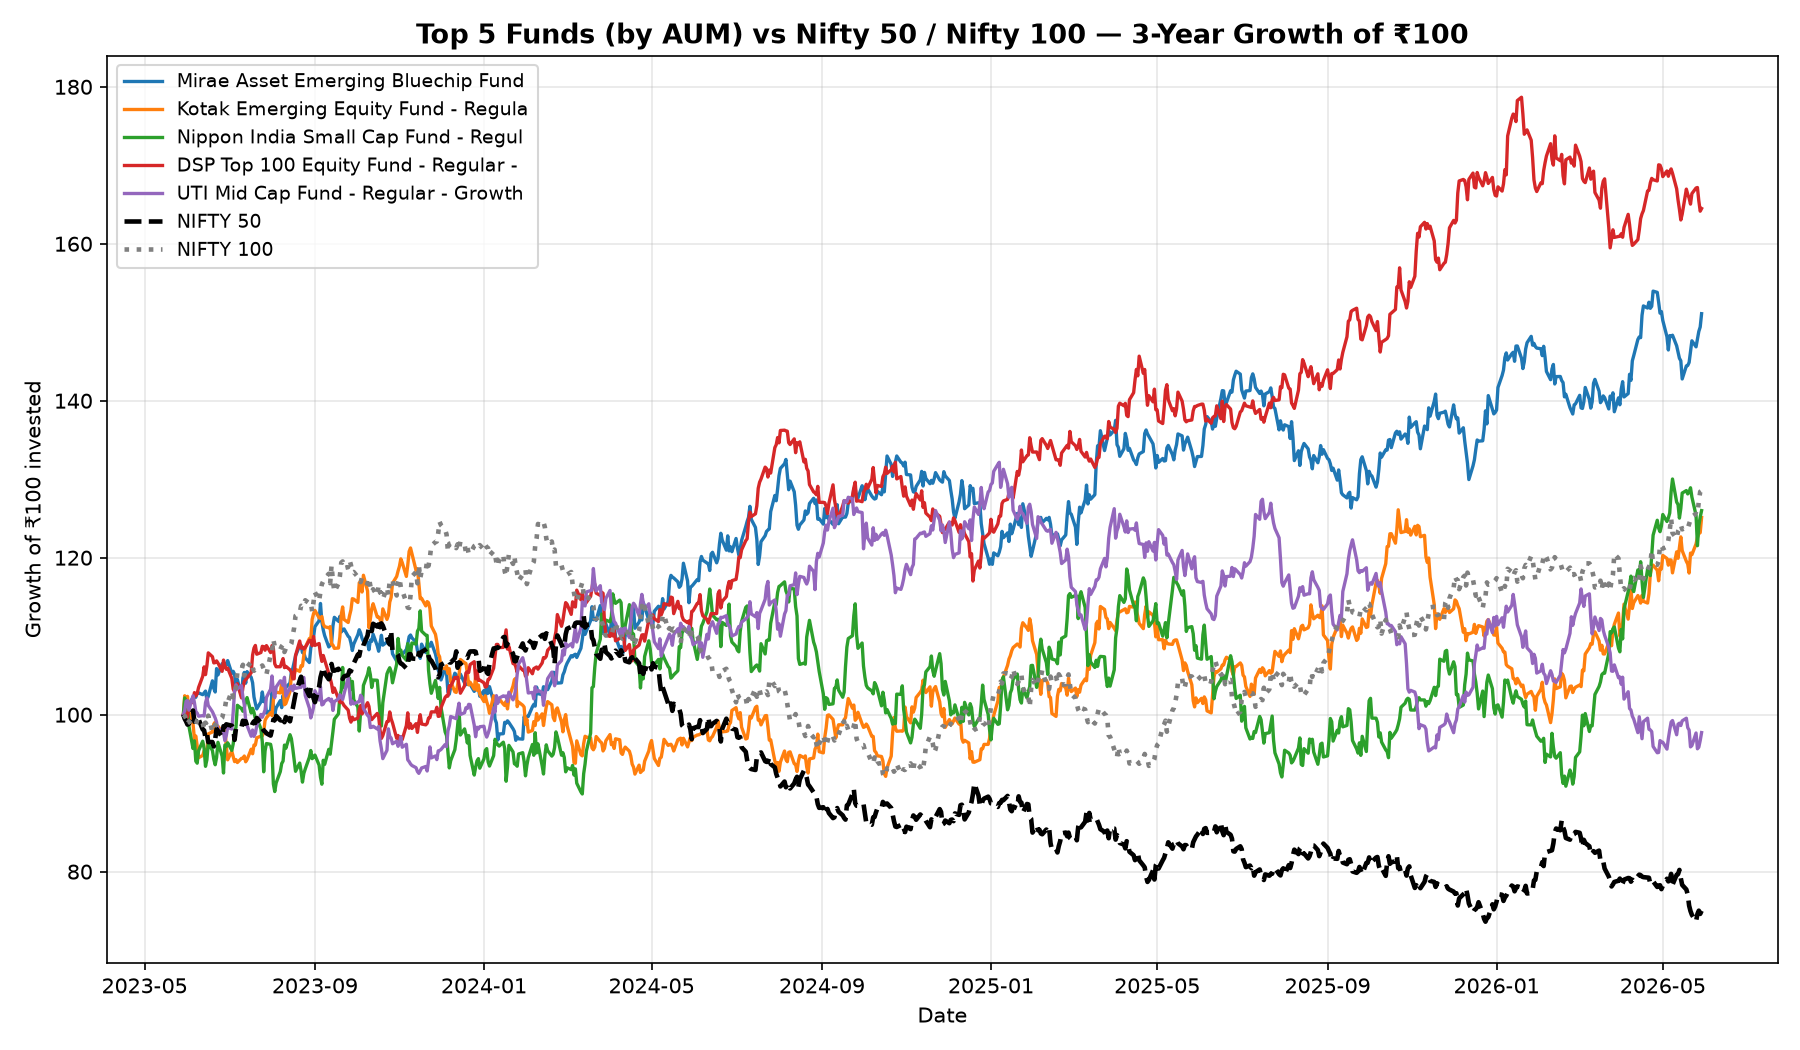

In [12]:

from IPython.display import Image
Image('reports/benchmark_comparison.png')


In [13]:

# Also show tracking error table
top5 = sc.head(5)
te_rows = []
for _, row in top5.iterrows():
    fr = nav[nav['amfi_code']==row['amfi_code']].set_index('date')['daily_return'].dropna()
    common = fr.index.intersection(n100.index)
    if len(common)>10:
        te = (fr.loc[common]-n100.loc[common]).std()*np.sqrt(252)*100
        te_rows.append({'Fund':row['scheme_name'][:35], 'Tracking Error (%)':round(te,2),
                        'Alpha':row['alpha'], 'Beta':row['beta']})
print(pd.DataFrame(te_rows).to_string(index=False))


                               Fund  Tracking Error (%)  Alpha   Beta
UTI Mid Cap Fund - Regular - Growth               22.56  0.029 -0.042
HDFC Top 100 Fund - Regular Plan -                19.93  0.037 -0.058
Axis Small Cap Fund - Regular - Gro               28.58  0.048 -0.067
ABSL Small Cap Fund - Regular - Gro               29.21  0.109 -0.065
Axis Bluechip Fund - Regular - Grow               18.91  0.069  0.010
